In [149]:
from huggingface_hub import login
import pandas as pd
from datasets import load_dataset
import zstandard as zstd
import requests
import io
import json
import random
import numpy as np

login()

# Ensure reproducibility
random.seed(42)

Load the data from Hugginface. We use two different repos: one for the train split, one for the test split

In [ ]:

TRAIN_ROWS_NEEDED = 5000 # True Members
TEST_ROWS_NEEDED = 5000   # True Non-Members
DOMAIN = "PubMed Abstracts" # domain


# function to filter the domain
def is_domain(example):
    return example["meta"]["pile_set_name"] == DOMAIN

# TRAIN DATA (MEMBERS)
# https://huggingface.co/datasets/monology/pile-uncopyrighted


print(f"--- Fetching {TRAIN_ROWS_NEEDED} Train Rows (Members) ---")

# 1. Load the streaming Parquet branch
train_dataset = load_dataset(
    "monology/pile-uncopyrighted", 
    split="train",
    revision="refs/convert/parquet",
    streaming=True
)


domain_train_stream = train_dataset.filter(is_domain)
train_members_list = list(domain_train_stream.take(TRAIN_ROWS_NEEDED))

# 3. Save to Parquet
df_train = pd.DataFrame(train_members_list)
df_train.to_parquet("../dataset/members.parquet")
print(f"Saved {len(df_train)} rows to dataset/members.parquet\n")


# TEST DATA (NON-MEMBERS)
# https://huggingface.co/datasets/mit-han-lab/pile-val-backup

print(f"--- Fetching {TEST_ROWS_NEEDED} Test Rows (Non-Members) ---")


# 1. Load the streaming Parquet branch
test_dataset = load_dataset(
    "mit-han-lab/pile-val-backup", 
    split="validation",
    revision="refs/convert/parquet",
    streaming=True
)

domain_test_stream = test_dataset.filter(is_domain)
test_non_members_list = list(domain_test_stream.take(TRAIN_ROWS_NEEDED))

# 2. Save to Parquet
df_test = pd.DataFrame(test_non_members_list)
df_test.to_parquet("../dataset/non_members.parquet")
print(f"Saved {len(df_test)} rows to dataset/non_members.parquet\n")

# VERIFICATION
print("--- Final Verification ---")
check_train = pd.read_parquet("../dataset/members.parquet")
check_test = pd.read_parquet("../dataset/non_members.parquet")

print(f"Members Dataset (Train): {check_train.shape[0]} rows")
print(f"Non-Members Dataset (Test): {check_test.shape[0]} rows")

--- Fetching 5000 Train Rows (Members) ---
Saved 5000 rows to dataset/members.parquet

--- Fetching 5000 Test Rows (Non-Members) ---
Saved 5000 rows to dataset/non_members.parquet

--- Final Verification ---
Members Dataset (Train): 5000 rows
Non-Members Dataset (Test): 5000 rows


In [150]:
members = pd.read_parquet("../dataset/members.parquet")
members = members['text']
non_members = pd.read_parquet("../dataset/non_members.parquet")
non_members = non_members['text']

type(members[0])

str

## 1. data leakage check.
since the members and non-members should, by definition, be completely separate dataset, we want to make sure that there is ovelap between them. 

In [165]:
# normalize the strings to cancel out differences like upper and lower case use
def normalize(series):
    return (
        series.astype(str)
              .str.strip()
              .str.lower()
              .str.replace(r'\s+', ' ', regex=True)
    )

clean_members = normalize(members)
clean_non_members = normalize(non_members)

# Find clean matches
matches = set(clean_members).intersection(clean_non_members)
print(f"matches: {len(matches)}")

matches: 0


## tokenize

In [152]:
# per-word token
# we split each string into singular words (e.g. 'we', 'split', 'each', ...)
m_tokens = members.astype(str).str.split()
nm_tokens = non_members.astype(str).str.split()

## 2. Time
there is no metadata that reports the time for the samples. However, we checked the actual text for time references.
The samples that contained time references were around 300. Since their presence could make the two datasets more distinguishable from each other, we dropped them.

In [ ]:
import re

YEAR_PATTERN = re.compile(r"^(18|19|20)\d{2}$")

# check each token for information about years (e.g. 1988, 2006, ...)
def get_year_indices(tokens_series):
    has_year = tokens_series.apply(
        lambda tokens: any(bool(YEAR_PATTERN.match(tok)) for tok in tokens)
    )
    return has_year[has_year].index.tolist()


# extract the indices of samples with information about time
m_years = get_year_indices(m_tokens)
nm_years = get_year_indices(nm_tokens)

print(f"members have {len(m_years)} mentions of years")
print(f"non-members have {len(nm_years)} mentions of years")

# because the samples with time reference are a small portion of the data, we can simply remove them
# we drop the samples both from the original dataset and the tokenized dataset

m_tokens = m_tokens.drop(index = m_years)
members = members.drop(index = m_years)

nm_tokens = nm_tokens.drop(index = nm_years)
non_members = non_members.drop(index = nm_years)

members have 368 mentions of years
non-members have 396 mentions of years


## 3. Length
We compare the length of the members and non-members to check they come from the same distribution

In [161]:
# store the length of each tokenized string
m_lengths = []
nm_lengths = []

for m, nm in zip(m_tokens, nm_tokens):
    m_lengths.append(len(m))
    nm_lengths.append(len(nm))


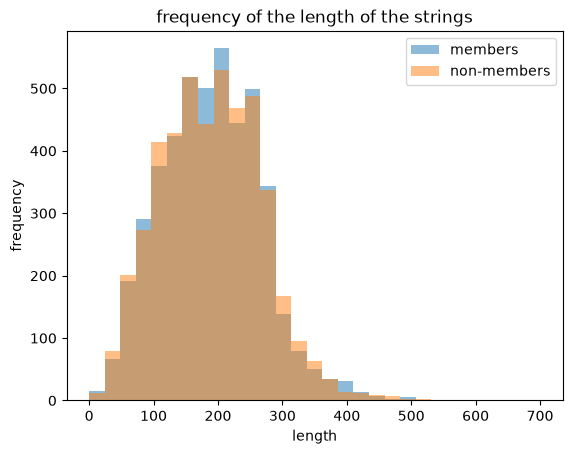

In [163]:
import matplotlib.pyplot as plt

# plot the frequency of the length of each sample
# the ditributions mostly overlap

bins = np.linspace(0, 700, 30)

plt.hist(m_lengths, bins, alpha=0.5, label='members')
plt.hist(nm_lengths, bins, alpha=0.5, label='non-members')
plt.xlabel("length")
plt.ylabel("frequency")
plt.legend(loc='upper right')
plt.title("frequency of the length of the strings")
plt.show()

In [164]:
# mean and median

data = {
  "mean": [np.mean(m_lengths), np.mean(nm_lengths)],
  "median": [np.median(m_lengths), np.median(nm_lengths)]
}

length_stats = pd.DataFrame(data, index = ["members", "non-members"])

print(length_stats)

                   mean  median
members      189.850348   189.0
non-members  190.032146   189.0


In [160]:
# 2 sample test
# because the p value > 0.05, we fail to reject the null hypothesis
# this means that there is no significant difference between the lengths of members and non-members

import scipy.stats as stats

print(np.var(m_lengths), np.var(nm_lengths))

print(stats.ttest_ind(a=m_lengths, b=nm_lengths, equal_var=True))

6086.869220122494 6390.140582623352
TtestResult(statistic=np.float64(-0.11042193983633494), pvalue=np.float64(0.9120771610389777), df=np.float64(9206.0))


## 4. Domain and source

Since we loaded the data directly from Huggingface and filtered it by domain, we are sure that both members and non-members share the same domain

## 5. Surface statistics

5.1 vocabulary overlap

In [204]:
from itertools import chain

# make sets from all the words
# use chain.from_iterable because each sample is a list of tokens
vocab_m = set(chain.from_iterable(m_tokens))
vocab_nm = set(chain.from_iterable(nm_tokens))

# words appearing in both datasets
common_words = vocab_m.intersection(vocab_nm)

# 4. Total combined vocabulary (union)
total_vocab = vocab_m | vocab_nm

print(f"Shared words: {len(common_words)}")
print(f"Total words: {len(total_vocab)}")

similarity = len(common_words) / len(total_vocab)
print(f"Vocabulary Overlap: common words / total words = {similarity:.2%}")

Shared words: 36892
Total words: 149841
Vocabulary Overlap: common words / total words = 24.62%


5.2 type-token ratio: diversity of the vocabulary

In [217]:
# to compute the type token ratio we use:
# the n. of unique words:  len(vocab_m)
# the n. of total words: m_tokens.str.len().sum()
# we compute the ratio between them

m_type = len(vocab_m) / m_tokens.str.len().sum()
print(f"type-token ratio for members: {m_type:.3%}")


nm_type = len(vocab_nm) / nm_tokens.str.len().sum()
print(f"type-token ratio for non-members: {nm_type:.3%}")

type-token ratio for members: 10.645%
type-token ratio for non-members: 10.650%


5.3 frequency of structural markers

In [ ]:
# patterns that might come up in Pubmed abstracts
PATTERNS = {
    "background": re.compile(
        r"\b(background|introduction|rationale|objective|aims?)\b[:\s]",
        re.I,
    ),
    "methods": re.compile(
        r"\b(methods?|methodology|materials? and methods?|study design|patients and methods)\b[:\s]",
        re.I,
    ),
    "results": re.compile(
        r"\b(results?|findings?|outcomes?)\b[:\s]", re.I
    ),
    "conclusions": re.compile(
        r"\b(conclusions?|discussion|significance|implications)\b[:\s]", re.I
    ),
}

In [248]:
# looks at whether a specific pattern appears at least once in a sample
def find_pattern(text):
    text_str = str(text)
    return {
        section: bool(pattern.search(text_str))
        for section, pattern in PATTERNS.items()
    }


# compute presence of pattern for both datasets and take the mean
m_stats = members.apply(find_pattern).apply(pd.Series).mean()
nm_stats = non_members.apply(find_pattern).apply(pd.Series).mean()

# make dataframe for visualization
comparison_df = pd.DataFrame({
    "Members (%)": (m_stats * 100).round(2),
    "Non-Members (%)": (nm_stats * 100).round(2),
})


print(comparison_df)

             Members (%)  Non-Members (%)
background          9.61            10.06
methods            12.33            11.60
results            36.20            36.23
conclusions         5.31             5.65


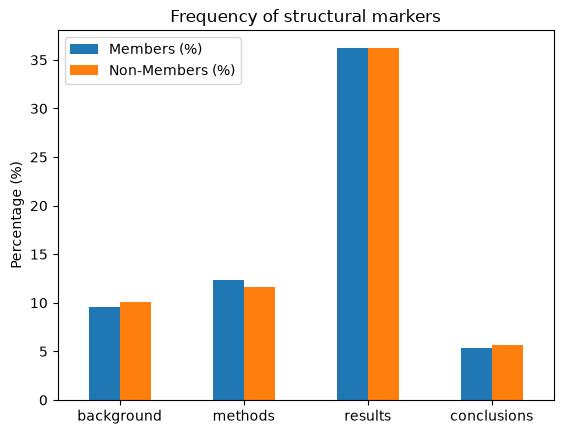

In [249]:
comparison_df[["Members (%)", "Non-Members (%)"]].plot(kind="bar")

plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.title("Frequency of structural markers")
plt.show()